In [2]:
import os, sys
import numpy as np
import pandas as pd

import scanpy as sc
import anndata as ad

In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [4]:
# david cb

In [4]:
David_ad = sc.read_h5ad("data/meahr/David_cb.h5ad")

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
David_ad

AnnData object with n_obs × n_vars = 10890 × 7102
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices'
    uns: 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'pseudodynamics_branch_class_colors', 'umap'
    obsm: 'X_dc', 'X_diffmap', 'X_pca', 'X_umap', 'diff component'
    varm: 'PCs'
    layers: 'Counts'
    obsp: 'connectivities', 'distances'

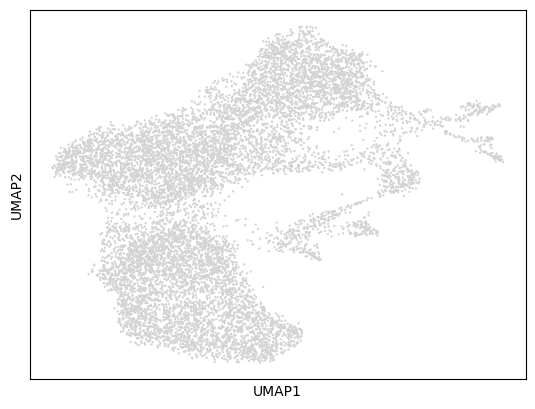

In [6]:
sc.pl.umap(David_ad)

In [7]:
nobranching = pd.read_csv("data/meahr/pdny_input/pseudodynamics_input_maehr17_monocle2_nobranching_TC.csv")

In [8]:
reg_expr = r"([A|T|C|G|N]{1,20})\S\w\d{1,2}.*"

In [9]:
nobranching['barcode'] = nobranching.cell.str.extract(reg_expr)

In [10]:
oligos = nobranching['cell'].str.extract(reg_expr)[0]
print(len(oligos))
oligos.nunique()

10705


10700

In [11]:
overlapped = 0
cbs = []
for t in sorted(David_ad.obs.time.unique()):
    
    ad_t_obs = David_ad.obs.query("`time` == @t")
    nb_cbs = nobranching.query("`time` == @t")['barcode'].values
    n_overlap = np.intersect1d(nb_cbs,ad_t_obs.barcodes.values)
    
    cb = ad_t_obs[ad_t_obs['barcodes'].isin(n_overlap)].index
    cbs.append(cb)

    print(len(n_overlap))
    overlapped += len(n_overlap)

442
1795
1052
1013
2616
1965
882
939


In [14]:
nobranching.query("`time` == @t & `barcode` in @n_overlap")

,branching_region,branch_class,time,batch,pseudotime,cell,barcode
9766,nonbranching,TC,19.5,P0_LeftLobe,22.910832,ACACGGTAATCC.P0_LeftLobe,ACACGGTAATCC
9767,nonbranching,TC,19.5,P0_LeftLobe,22.934998,GTTCGTTAGGCC.P0_LeftLobe,GTTCGTTAGGCC
9768,nonbranching,TC,19.5,P0_LeftLobe,12.269009,ATATGCGCTACN.P0_LeftLobe,ATATGCGCTACN
9769,nonbranching,TC,19.5,P0_LeftLobe,15.926813,GGGAGCATACCA.P0_LeftLobe,GGGAGCATACCA
9770,nonbranching,TC,19.5,P0_LeftLobe,24.576078,TGGCACAGCGTG.P0_LeftLobe,TGGCACAGCGTG
...,...,...,...,...,...,...,...
10700,nonbranching,TC,19.5,P0_RightLobe,9.201721,CATACGCCTAGN.P0_RightLobe,CATACGCCTAGN
10701,nonbranching,TC,19.5,P0_RightLobe,13.435288,AGAAGAGTCGCN.P0_RightLobe,AGAAGAGTCGCN
10702,nonbranching,TC,19.5,P0_RightLobe,28.642268,CAAACCCGTCAN.P0_RightLobe,CAAACCCGTCAN
10703,nonbranching,TC,19.5,P0_RightLobe,6.808191,CCTTTCCGCGAC.P0_RightLobe,CCTTTCCGCGAC


In [63]:
cbs = np.concatenate(cbs, axis=0)

In [64]:
unique_cb, counts = np.unique(cbs,return_counts=True)

In [67]:
true_unique_cb = unique_cb[np.where(counts==1)[0]]

In [68]:
len(true_unique_cb)

10700

In [52]:
David_ad

AnnData object with n_obs × n_vars = 10890 × 7102
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices'
    uns: 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'pseudodynamics_branch_class_colors', 'umap'
    obsm: 'X_dc', 'X_diffmap', 'X_pca', 'X_umap', 'diff component'
    varm: 'PCs'
    layers: 'Counts'
    obsp: 'connectivities', 'distances'

In [70]:
selected_ad = David_ad[David_ad.obs_names.isin(true_unique_cb)]
unique_cb_2, counts = np.unique(selected_ad.obs_names,return_counts=True)
true_unique_cb2 = unique_cb_2[np.where(counts==1)[0]]

In [73]:
nonbranding_ad = David_ad[David_ad.obs_names.isin(true_unique_cb2)]

In [77]:
clu_remove = ['']
David_ad.obs.query('`leiden` not in @clu')

AnnData object with n_obs × n_vars = 10890 × 7102
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices'
    uns: 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'pseudodynamics_branch_class_colors', 'umap'
    obsm: 'X_dc', 'X_diffmap', 'X_pca', 'X_umap', 'diff component'
    varm: 'PCs'
    layers: 'Counts'
    obsp: 'connectivities', 'distances'

In [84]:
remove_clu = ['14','16','17','13']
single_branch = nonbranding_ad[nonbranding_ad.obs.query("`leiden` not in @remove_clu").index]

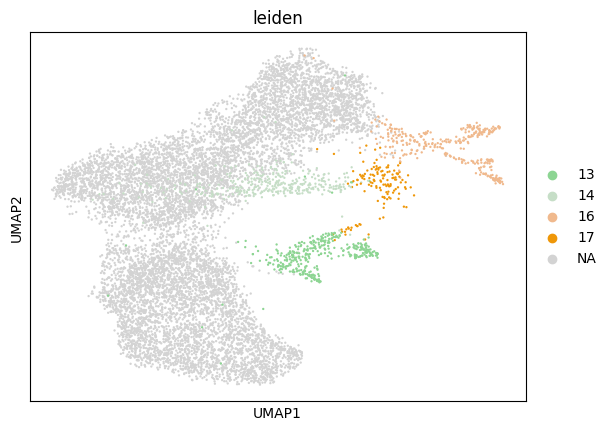

In [82]:
sc.pl.umap(nonbranding_ad, color='leiden', groups=['14','16','17','13'])

In [86]:
import palantir

In [85]:
single_branch

View of AnnData object with n_obs × n_vars = 9485 × 7102
    obs: 'barcodes', 'batch_x', 'pseudodynamics_branching_region', 'pseudodynamics_branch_class', 'dpt_adjusted_groups', 'time', 'batch_y', 'pseudotime', 'cell', 'dc1', 'dc2', 'dc3', 'dc4', 'batch_to_match', 'leiden', 'Time_x', 'Time_y', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices'
    uns: 'Time_x_colors', 'Time_y_colors', 'diffmap_evals', 'dpt_changepoints', 'dpt_grouptips', 'iroot', 'leiden', 'leiden_colors', 'leiden_sizes', 'log1p', 'neighbors', 'paga', 'pca', 'pseudodynamics_branch_class_colors', 'umap'
    obsm: 'X_dc', 'X_diffmap', 'X_pca', 'X_umap', 'diff component'
    varm: 'PCs'
    layers: 'Counts'
    obsp: 'connectivities', 'distances'

In [87]:
# Run diffusion maps
dm_res = palantir.utils.run_diffusion_maps(single_branch)
ms_data = palantir.utils.determine_multiscale_space(single_branch)
imputed_X = palantir.utils.run_magic_imputation(single_branch)

TGTGTCCATTAT.E18_5_WholeThy_rep1
ACCTTAGGCGCC.E12_5_WholeThy_venus_rep3


(<Figure size 400x400 with 1 Axes>, <Axes: >)

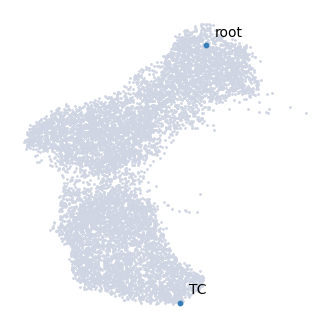

In [88]:
# # terminal mk
# nk_cells =  single_branch.obs.query('`pseudodynamics_branch_class` == "NK" & `Time_x` == "P0"')
# nk_terminal_idx = nk_cells.pseudotime.argmax()
# nk_terminal_cb = nk_cells.iloc[nk_terminal_idx].name
# print(nk_terminal_cb)

# terminal ery
tc_cells =  single_branch.obs.query('`pseudodynamics_branch_class` == "TC"')
tc_terminal_idx = tc_cells.pseudotime.argmax()
tc_terminal_cb = tc_cells.iloc[tc_terminal_idx].name
print(tc_terminal_cb)

# root
root_idx = single_branch.obs.pseudotime.argmin()
root_cb = single_branch.obs.iloc[root_idx].name
print(root_cb)
all_states = pd.Series(
    ["TC", "root"],
    index=[tc_terminal_cb, root_cb],
)

terminal_states = pd.Series(
    ["TC"],
    index=[tc_terminal_cb],
)
palantir.plot.highlight_cells_on_umap(single_branch, all_states)

In [90]:
start_cell = root_cb
pr_res = palantir.core.run_palantir(
    single_branch, start_cell, knn=30, num_waypoints=500,  terminal_states=terminal_states
)

Sampling and flocking waypoints...


Time for determining waypoints: 0.005990314483642578 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 1.0722835699717204 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


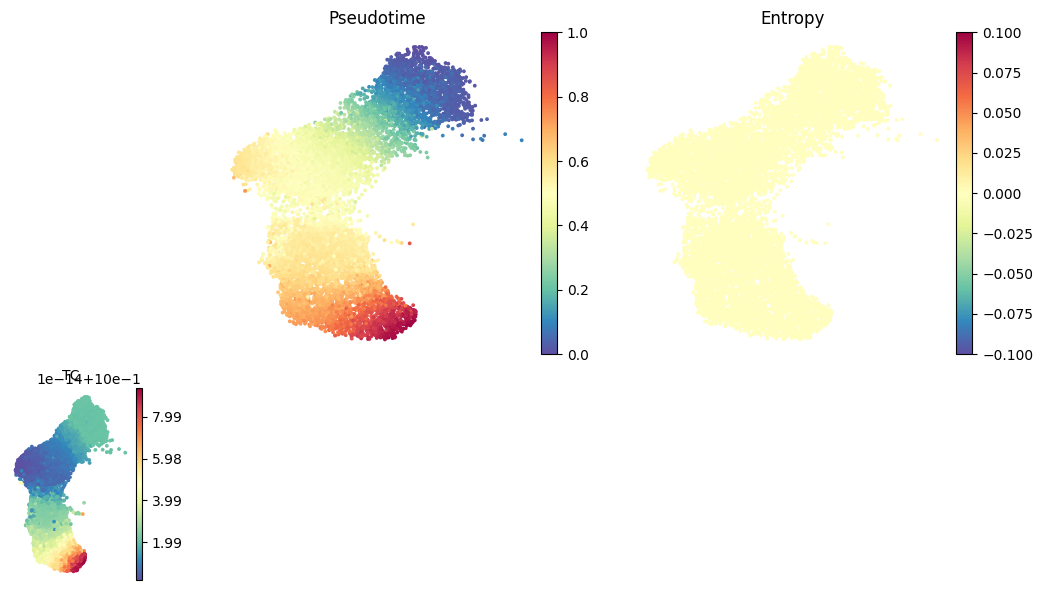

In [91]:
palantir.plot.plot_palantir_results(single_branch, s=3);

# add population size

In [93]:
popsize= pd.read_csv("data/meahr/pdny_input/pseudodynamics_input_maehr17_popsize.csv")

In [95]:
weinreb = sc.read_h5ad("data/klein_subset.h5ad")

In [96]:
weinreb.uns['pop']

{'mean': array([24000, 30000, 36000]),
 'n_lib': array([3, 3, 3]),
 't': array([2, 4, 6]),
 'var': array([  4898,  24494, 187082])}

In [ ]:
pop = {}
pop['t'] = popsize['day'].values
pop['mean'] = popsize['CellsPerLobe'].values
pop['var'] = popsize['sd'].values**2
pop['n_lib'] = popsize['replicates'].values

single_branch.uns['pop'] = pop

In [98]:
single_branch.uns['pop'] 

{'t': array([12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 'mean': array([   16700,    28200,    86400,   236000,   979000,  2245000,
         5350000, 15630000]),
 'var': array([    44890000,    179560000,    894010000,   8574760000,
         67600000000, 222784000000, 605000841124, 793800812025]),
 'n_lib': array([5, 5, 5, 5, 5, 5, 2, 2])}

In [104]:
DM = single_branch.obsm['DM_EigenVectors_multiscaled']
DM_std = DM / DM.std(axis=0)
single_branch.obsm['DM_EigenVectors_multiscaled_std'] = DM_std

In [109]:
single_branch.obs['timepoint_tx_days'] = single_branch.obs.time.values

In [113]:
from scipy.sparse import csr_matrix

In [115]:
single_branch.obsp['connectivities'] = csr_matrix(single_branch.obsp['connectivities'])

In [116]:
single_branch.write_h5ad("data/David_non_branching.h5ad")

# test density

In [1]:
from PINN import reader, tl, pl

In [5]:
meahr_monocle = sc.read_h5ad("data/meahr_monocle.h5ad")

In [ ]:
delta_DM = []
for i in range(40):
    sample_deltax = tl.sample_deltax(meahr_monocle, xkey='DM_EigenVectors_multiscaled', progressbar=False)
    delta_s , neighbors = sample_deltax
    delta_DM.append(delta_s)

delta_DM_mean = np.stack(delta_DM).mean(axis=0)
meahr_monocle.obsm['Delta_DM'] = delta_DM_mean

In [8]:
meahr_monocle.write_h5ad("data/meahr_monocle.h5ad")

In [123]:
delta_DM = []
for i in range(40):
    sample_deltax = tl.sample_deltax(single_branch, xkey='DM_EigenVectors_multiscaled_std', progressbar=False)
    delta_s , neighbors = sample_deltax
    delta_DM.append(delta_s)

In [129]:
delta_DM_mean = np.stack(delta_DM).mean(axis=0)

single_branch.obsm['Delta_DM_std'] = delta_DM_mean


In [146]:
single_branch.write_h5ad("data/David_non_branching.h5ad")

In [131]:
single_branch.uns['pop']

{'t': array([12.5, 13.5, 14.5, 15.5, 16.5, 17.5, 18.5, 19.5]),
 'mean': array([   16700,    28200,    86400,   236000,   979000,  2245000,
         5350000, 15630000]),
 'var': array([    44890000,    179560000,    894010000,   8574760000,
         67600000000, 222784000000, 605000841124, 793800812025]),
 'n_lib': array([5, 5, 5, 5, 5, 5, 2, 2])}

In [133]:
train_DS = reader.TwoTimpepoint_AnnDS(
                    AnnData=single_branch, 
                    timepoint_idx=None, 
                    n_dimension = 3,
                    cellstate_key='DM_EigenVectors_multiscaled_std',  #'DM_EigenVector'
                    log_transform=False,
                    norm_time='mean_minus',
                    deltax_key='Delta_DM_std',
                    batchsize=200)


Computing density :
`density_funs` not specified, use gaussian kde


In [137]:
u = train_DS.u_b.cpu().numpy()

prediction of shape (8, 9485)


prediction of shape (8, 9485)


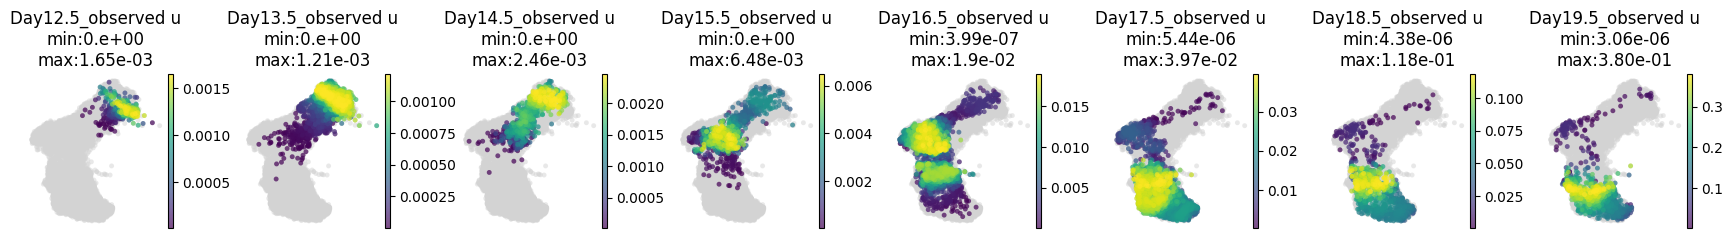

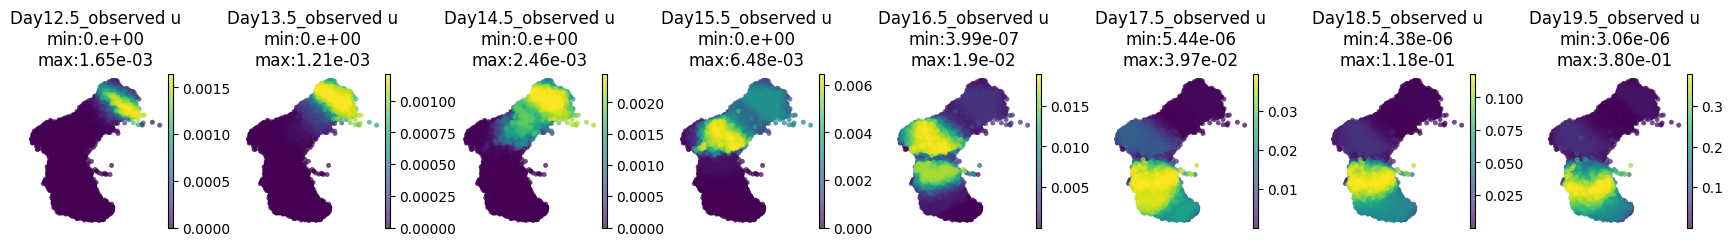

In [139]:
pl.params_in_umap(single_branch, u, param='observed u');
pl.params_in_umap(single_branch, u, param='observed u', cell_of_t=False);

In [158]:
single_branch.obs['pseudotime_bin'] = pd.cut(single_branch.obs['palantir_pseudotime'], bins=300,
                                             labels = np.linspace(0,1,300))

In [141]:
for i,t in enumerate(pop['t']):
    single_branch.obs['u_%s'%t] = u[i]

In [148]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
single_branch.obs['pseudotime_bin'] = pd.cut(single_branch.obs['palantir_pseudotime'], bins=300,
                                             labels = np.linspace(0,1,300))
fig, axs = plt.subplots(2,4, figsize=(15,6), gridspec_kw={"wspace":0.4, 'hspace':0.3})
axs = axs.flatten()
for i,t in enumerate(pop['t']):
    data = single_branch.obs[['pseudotime_bin','u_%s'%t]]
    gdata = data.groupby("pseudotime_bin").agg("mean").reset_index()
    sns.scatterplot(data=gdata, x='pseudotime_bin', y='u_%s'%t, ax=axs[i], alpha=0.3)

# pseudodynamics_input_maehr17wrag_dpt_branching_TCandNK

In [3]:
# load df
input = pd.read_csv("/ssd/users/Wergillius/Project/PINN_dynamics/data/meahr/pdny_input/pseudodynamics_input_maehr17wrag_dpt_branching_TCandNK.csv")

In [6]:
input['dpt_adjusted_groups'].unique()

array(['intermediate', 'TC', 'NK', 'progenitor'], dtype=object)

In [11]:
input['batch'].unique()

array(['Rag1KO_WholeThy_rep1', 'Rag1KO_WholeThy_rep2',
       'Rag2null_E14_5_WholeThy_rep1', 'e12_5wholeThy_venus_rep3',
       'e13_5wholeThy_wt_rep3', 'E15_5_WholeThy_Rep1',
       'E15_5_WholeThy_Rep2', 'e12_5wholeThy_venus',
       'e12_5wholeThy_venus_rep2', 'E14_5_WholeThy_rep2',
       'e13_5_wholeThymus_wt_rep4', 'e13_5_wholeThymus_wt_rep5',
       'e16_5_wholeThymus_wt_rep1', 'E16_5_WholeThy_Rep2_combine',
       'E16_5_WholeThy_Rep3_combine', 'E14_5_WholeThy_rep4',
       'E17_5_WholeThy_rep1', 'E17_5_WholeThy_rep2',
       'E18_5_WholeThy_rep1', 'E18_5_WholeThy_rep2', 'P0_LeftLobe',
       'P0_RightLobe'], dtype=object)

In [14]:
print(input.query("`batch` == 'Rag1KO_WholeThy_rep1'").time.unique())
print(input.query("`batch` == 'Rag1KO_WholeThy_rep2'").time.unique())
print(input.query("`batch` == 'Rag2null_E14_5_WholeThy_rep1'").time.unique())

[16.5]
[16.5]
[14.5]


array([16.5])